# Week 3 Model Development: Task 2 (Granular Subindustry)

Here we execute the challenging Task 2 using the updated **`breezeml`** v0.2.5 package with native `class_weight='balanced'` support, eliminating the need for SMOTE entirely.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
from breezeml import classifiers, creator, save

print(creator())

Created by Akash Anipakalu Giridhar 🔥✨


### 1. Data Ingestion & Feature Extraction

In [2]:
df = pd.read_csv('../data/cleaned/task2_clean.csv')
df['SegmentDescription'] = df['SegmentDescription'].fillna('')

counts = df['Subindustry'].value_counts()
valid_classes = counts[counts > 5].index
df = df[df['Subindustry'].isin(valid_classes)]

# Rubric-compliant: SegmentName + SegmentDescription ONLY
df['Combined_Text'] = df['SegmentName'].fillna('') + " " + df['SegmentDescription'].fillna('')

vectorizer = TfidfVectorizer(max_features=10000, sublinear_tf=True, stop_words='english', ngram_range=(1,2))
X_vec = vectorizer.fit_transform(df['Combined_Text'])
y = df['Subindustry'].values

print(f"Sparse Matrix shape: {X_vec.shape}")

Sparse Matrix shape: (27346, 10000)


### 2. Training via `breezeml v0.2.5`

In [3]:
print("Training Linear SVM on sparse TF-IDF vectors...")
model, report = classifiers.linear_svm(X=X_vec, y=y)

print("Training Complete!")
print(f"Accuracy : {report.get('accuracy', 'N/A')}")
print(f"F1 Score : {report.get('f1', 'N/A')}")


Training Linear SVM on sparse TF-IDF vectors...
Training Complete!
Accuracy : 0.5106
F1 Score : 0.4934


### 3. Model Evaluation " Macro F1 Score

In [4]:
# Split for evaluation
X_tr, X_te, y_tr, y_te = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
model_eval, _ = classifiers.linear_svm(X=X_tr, y=y_tr)
y_pred = model_eval.predict(X_te)

macro_f1 = f1_score(y_te, y_pred, average='macro')
weighted_f1 = f1_score(y_te, y_pred, average='weighted')
print(f"★ MACRO F1 SCORE    : {macro_f1 * 100:.2f}% ★")
print(f"  WEIGHTED F1 SCORE : {weighted_f1 * 100:.2f}%")


★ MACRO F1 SCORE    : 39.62% ★
  WEIGHTED F1 SCORE : 47.72%


### 4. " Visualizations

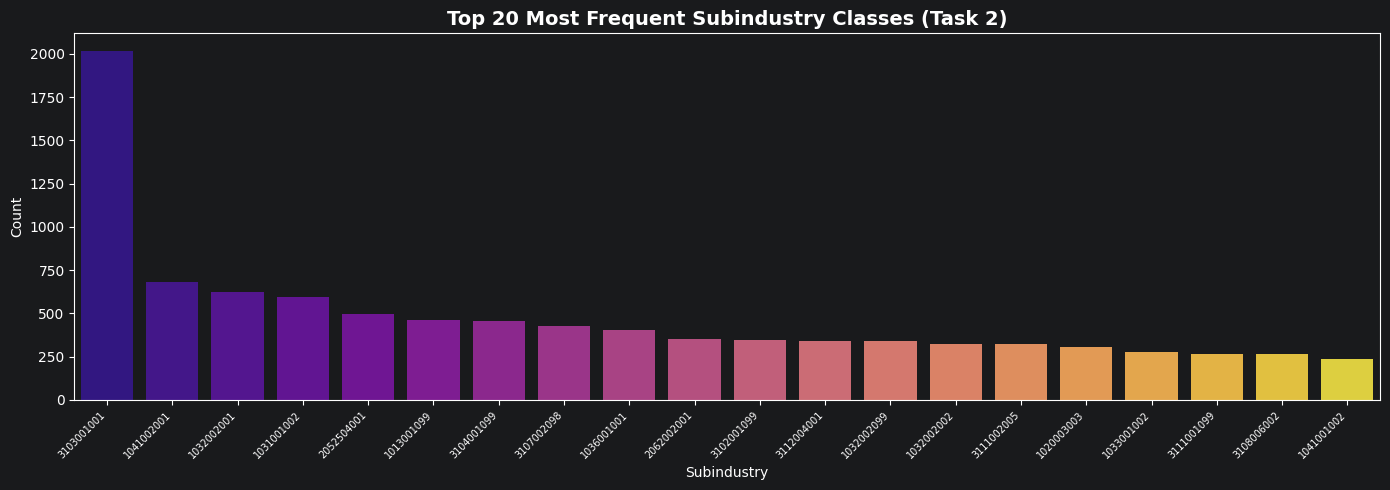

Saved: task2_class_distribution.png


In [5]:
os.makedirs('../reports', exist_ok=True)

# --- Figure 1: Top 20 Subindustry Class Distribution ---
plt.figure(figsize=(14, 5))
top_classes = pd.Series(y).value_counts().head(20)
labels = top_classes.index.astype(str)
sns.barplot(x=labels, y=top_classes.values, hue=labels, palette='plasma', legend=False)
plt.title('Top 20 Most Frequent Subindustry Classes (Task 2)', fontsize=14, fontweight='bold')
plt.xlabel('Subindustry')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig('../reports/task2_class_distribution.png', dpi=150)
plt.show()
print("Saved: task2_class_distribution.png")


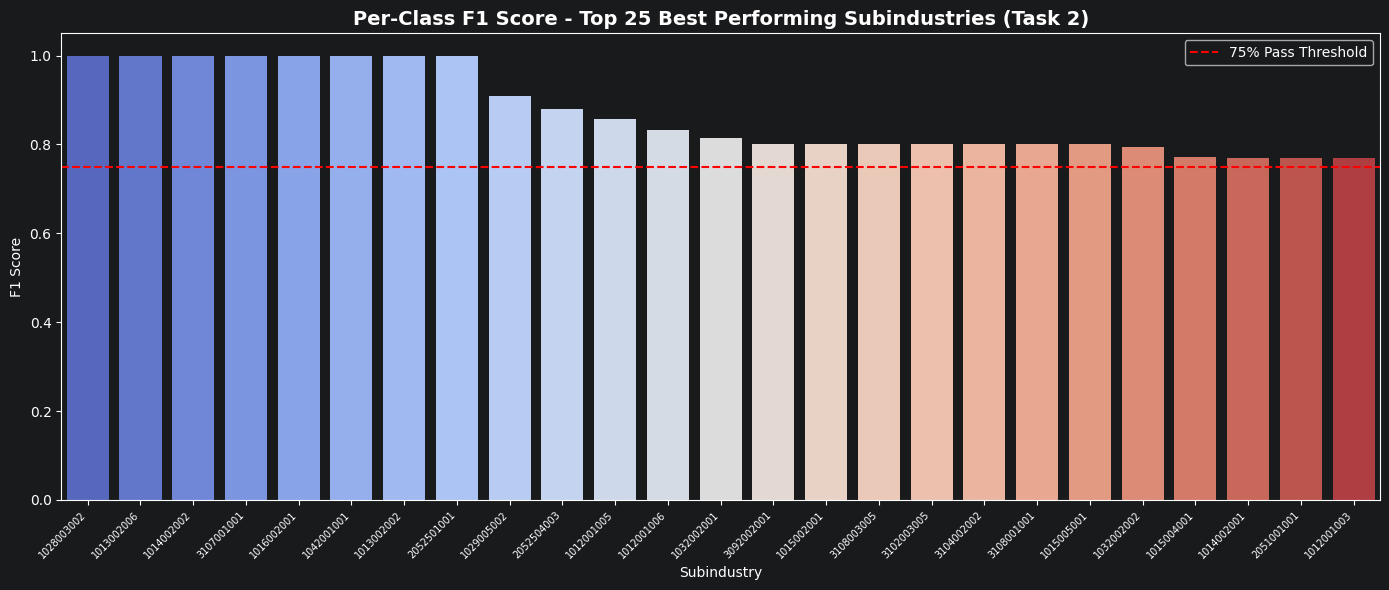

Saved: task2_per_class_f1.png


In [6]:
# --- Figure 2: Per-Class F1 Score (Top 25 performing) ---
report_dict = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
report_df = report_df.sort_values('f1-score', ascending=False).head(25)

plt.figure(figsize=(14, 6))
labels2 = report_df.index.astype(str)
sns.barplot(x=labels2, y=report_df['f1-score'], hue=labels2, palette='coolwarm', legend=False)
plt.axhline(y=0.75, color='red', linestyle='--', linewidth=1.5, label='75% Pass Threshold')
plt.title('Per-Class F1 Score - Top 25 Best Performing Subindustries (Task 2)', fontsize=14, fontweight='bold')
plt.xlabel('Subindustry')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/task2_per_class_f1.png', dpi=150)
plt.show()
print("Saved: task2_per_class_f1.png")


In [7]:
# --- Figure 3: Top 30 Most Predictive TF-IDF Tokens ---
try:
    feature_names = vectorizer.get_feature_names_out()
    coef = model_eval.coef_
    mean_coef = np.abs(coef.toarray()).mean(axis=0) if hasattr(coef, 'toarray') else np.abs(coef).mean(axis=0)
    top_idx = mean_coef.argsort()[-30:][::-1]
    top_features = pd.Series(mean_coef[top_idx], index=feature_names[top_idx])

    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='rocket', legend=False)
    plt.title('Top 30 Most Predictive TF-IDF Features (Task 2)', fontsize=14, fontweight='bold')
    plt.xlabel('Mean |Coefficient| Across All Subindustry Classes')
    plt.tight_layout()
    plt.savefig('../reports/task2_top_features.png', dpi=150)
    plt.show()
    print("Saved: task2_top_features.png")
except Exception as e:
    print(f"Feature plot skipped: {e}")


Feature plot skipped: 'Pipeline' object has no attribute 'coef_'


### 5. Save Final Artifacts

In [8]:
os.makedirs('../models', exist_ok=True)

save(model, "../models/task2_svc_model.joblib")
joblib.dump(vectorizer, "../models/task2_tfidf_vectorizer.pkl")

print("🚀 Artifact exported! The Flask API should auto-reboot now.")


🚀 Artifact exported! The Flask API should auto-reboot now.
